<a href="https://colab.research.google.com/github/ananya04-s/Machinelearning/blob/main/MACHINELEARNING_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data = pd.DataFrame([
    ['High', 'Large', 'Dell', 'Cheap', 'Yes'],
    ['High', 'Large', 'HP', 'Cheap', 'Yes'],
    ['Medium', 'Large', 'Dell', 'Medium', 'No'],
    ['High', 'Small', 'Dell', 'Cheap', 'Yes'],
    ['Low', 'Large', 'HP', 'Expensive', 'No']
], columns=['RAM', 'Storage', 'Brand', 'Price', 'Buy'])

print("DATASET:")
print(data, "\n")


# -------------------
# Find-S Algorithm
# -------------------
def find_s(examples):
    positive_examples = examples[examples['Buy'] == 'Yes']
    hypothesis = positive_examples.iloc[0, :-1].tolist()

    for i in range(1, len(positive_examples)):
        for attr in range(len(hypothesis)):
            if positive_examples.iloc[i, attr] != hypothesis[attr]:
                hypothesis[attr] = '?'

    return hypothesis


final_hypothesis = find_s(data)
print("Final Hypothesis using Find-S:\n", final_hypothesis, "\n")


# -------------------------------
# Candidate Elimination Algorithm
# -------------------------------
def candidate_elimination(examples):
    attributes = list(examples.columns[:-1])
    S = [['Ø'] * len(attributes)]
    G = [['?'] * len(attributes)]

    for i, row in examples.iterrows():
        instance = row[:-1].tolist()
        label = row[-1]

        # Positive example
        if label == 'Yes':
            # Remove inconsistent hypotheses from G
            G = [
                g for g in G
                if all(g[j] == '?' or g[j] == instance[j] for j in range(len(attributes)))
            ]

            # Update S
            for s in S:
                for j in range(len(s)):
                    if s[j] == 'Ø':
                        s[j] = instance[j]
                    elif s[j] != instance[j]:
                        s[j] = '?'

        # Negative example
        else:
            # Remove inconsistent hypotheses from S
            S = [
                s for s in S
                if not all(s[j] == instance[j] or s[j] == '?' for j in range(len(attributes)))
            ]

            # Specialize G
            new_G = []
            for g in G:
                if all(g[j] == '?' or g[j] == instance[j] for j in range(len(attributes))):
                    for j in range(len(attributes)):
                        if g[j] == '?':
                            for value in examples[attributes[j]].unique():
                                if value != instance[j]:
                                    new_hypothesis = g.copy()
                                    new_hypothesis[j] = value
                                    new_G.append(new_hypothesis)
                        else:
                            new_G.append(g)
            G = new_G

        # Keep only hypotheses consistent with S
        G = [
            g for g in G
            if all(any(g[j] == '?' or s[j] == '?' or g[j] == s[j]
                       for j in range(len(attributes)))
                   for s in S)
        ]

    return S, G


S_final, G_final = candidate_elimination(data)

print("Most Specific Hypothesis (S):\n", S_final)
print("Most General Hypothesis (G):\n", G_final)


DATASET:
      RAM Storage Brand      Price  Buy
0    High   Large  Dell      Cheap  Yes
1    High   Large    HP      Cheap  Yes
2  Medium   Large  Dell     Medium   No
3    High   Small  Dell      Cheap  Yes
4     Low   Large    HP  Expensive   No 

Final Hypothesis using Find-S:
 ['High', '?', '?', 'Cheap'] 

Most Specific Hypothesis (S):
 [['High', '?', '?', 'Cheap']]
Most General Hypothesis (G):
 []


/tmp/ipython-input-200561884.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[-1]


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text
data = pd.DataFrame([
['Sunny', 'Hot', 'High', 'Weak', 'No'],
['Sunny', 'Hot', 'High', 'Strong', 'No'],
['Overcast', 'Hot', 'High', 'Weak', 'Yes'],
['Rain', 'Mild', 'High', 'Weak', 'Yes'],
['Rain', 'Cool', 'Normal', 'Weak', 'Yes'],
['Rain', 'Cool', 'Normal', 'Strong', 'No'],
['Overcast', 'Cool', 'Normal', 'Strong', 'Yes'],
['Sunny', 'Mild', 'High', 'Weak', 'No'],
['Sunny', 'Cool', 'Normal', 'Weak', 'Yes'],
['Rain', 'Mild', 'Normal', 'Weak', 'Yes'],
['Sunny', 'Mild', 'Normal', 'Strong', 'Yes'],
['Overcast', 'Mild', 'High', 'Strong', 'Yes'],
['Overcast', 'Hot', 'Normal', 'Weak', 'Yes'],
['Rain', 'Mild', 'High', 'Strong', 'No']
], columns=['Outlook', 'Temp', 'Humidity', 'Wind', 'Play'])
data_encoded = pd.get_dummies(data[['Outlook', 'Temp', 'Humidity', 'Wind']])
y = data['Play'].map({'No':0, 'Yes':1})
model = DecisionTreeClassifier(criterion='entropy', max_depth=3)
model.fit(data_encoded, y)
rules = export_text(model, feature_names=list(data_encoded.columns))
print("=== Example-Based Rules (CN2-like) ===")
print(rules)
print("\n=== FOIL Rule Learning (Conceptual Output) ===")
foil_rules = [
"IF Outlook = Overcast THEN Play = Yes",
"IF Humidity = Normal AND Wind = Weak THEN Play = Yes",
"IF Outlook = Sunny AND Humidity = High THEN Play = No"
]
for r in foil_rules:
  print(r)


=== Example-Based Rules (CN2-like) ===
|--- Outlook_Overcast <= 0.50
|   |--- Humidity_Normal <= 0.50
|   |   |--- Outlook_Rain <= 0.50
|   |   |   |--- class: 0
|   |   |--- Outlook_Rain >  0.50
|   |   |   |--- class: 0
|   |--- Humidity_Normal >  0.50
|   |   |--- Wind_Strong <= 0.50
|   |   |   |--- class: 1
|   |   |--- Wind_Strong >  0.50
|   |   |   |--- class: 0
|--- Outlook_Overcast >  0.50
|   |--- class: 1


=== FOIL Rule Learning (Conceptual Output) ===
IF Outlook = Overcast THEN Play = Yes
IF Humidity = Normal AND Wind = Weak THEN Play = Yes
IF Outlook = Sunny AND Humidity = High THEN Play = No


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)
bag_model = BaggingClassifier(
estimator=DecisionTreeClassifier(),
n_estimators=10,
random_state=42
)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)
boost_model = AdaBoostClassifier(
estimator=DecisionTreeClassifier(max_depth=1),
n_estimators=50,
learning_rate=1.0,
random_state=42
)
boost_model.fit(X_train, y_train)
y_pred_boost = boost_model.predict(X_test)
bag_acc = accuracy_score(y_test, y_pred_bag)
boost_acc = accuracy_score(y_test, y_pred_boost)
print("=== Bagging Classification Report ===")
print(classification_report(y_test, y_pred_bag))
print("\n=== Boosting Classification Report ===")
print(classification_report(y_test, y_pred_boost))
print("\nBagging Accuracy: {:.2f}%".format(bag_acc * 100))
print("Boosting Accuracy: {:.2f}%".format(boost_acc * 100))


=== Bagging Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


=== Boosting Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Bagging Accuracy: 100.00%
Boosting Accuracy: 100.00%


DATASET (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Cluster Centers (after scaling):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]

Clustered Data (first 10 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3     

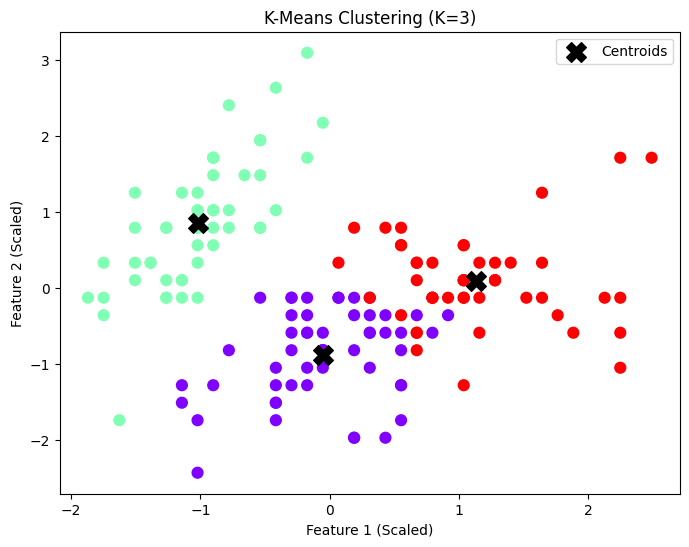

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X = iris.data
df = pd.DataFrame(X, columns=iris.feature_names)
print("DATASET (first 5 rows):")
print(df.head())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_
print("\nCluster Centers (after scaling):")
print(kmeans.cluster_centers_)
print("\nClustered Data (first 10 rows):")
print(df.head(10))
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='rainbow', s=60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
color='black', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering (K=3)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend()
plt.show()

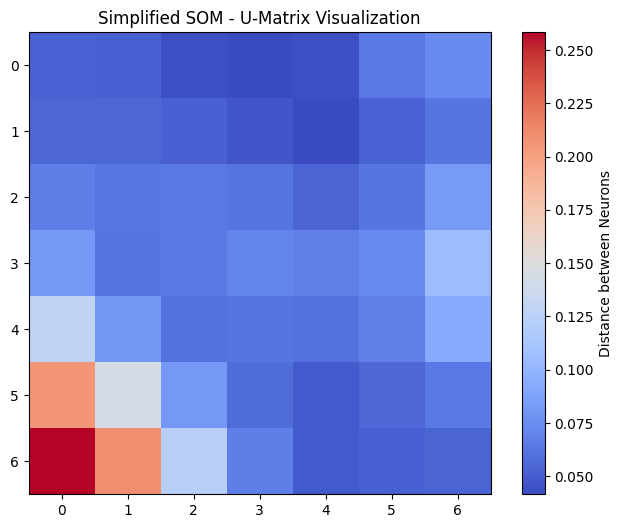

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Normalize the data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# SOM Parameters
m, n = 7, 7
input_len = X_scaled.shape[1]
learning_rate = 0.5
num_epochs = 100

# Initialize weight vectors
weights = np.random.rand(m, n, input_len)

# Training SOM
for epoch in range(num_epochs):
    for x in X_scaled:
        # Compute distance of sample x to all neurons
        distances = np.linalg.norm(weights - x, axis=2)

        # Find Best Matching Unit (BMU)
        bmu_index = np.unravel_index(np.argmin(distances), (m, n))
        bmu = weights[bmu_index]

        # Update weights
        for i in range(m):
            for j in range(n):
                dist_to_bmu = np.linalg.norm(np.array([i, j]) - np.array(bmu_index))
                h = np.exp(-dist_to_bmu**2 / (2 * (1.5 ** 2)))  # neighborhood function
                weights[i, j] += learning_rate * h * (x - weights[i, j])

# Compute U-Matrix
u_matrix = np.zeros((m, n))

for i in range(m):
    for j in range(n):
        neighbor_dists = []

        if i > 0:
            neighbor_dists.append(np.linalg.norm(weights[i, j] - weights[i-1, j]))
        if i < m-1:
            neighbor_dists.append(np.linalg.norm(weights[i, j] - weights[i+1, j]))
        if j > 0:
            neighbor_dists.append(np.linalg.norm(weights[i, j] - weights[i, j-1]))
        if j < n-1:
            neighbor_dists.append(np.linalg.norm(weights[i, j] - weights[i, j+1]))

        u_matrix[i, j] = np.mean(neighbor_dists)

# Plot U-Matrix
plt.figure(figsize=(8, 6))
plt.title("Simplified SOM - U-Matrix Visualization")
plt.imshow(u_matrix, cmap='coolwarm')
plt.colorbar(label='Distance between Neurons')
plt.show()


In [ ]:
import numpy as np

# Generate uniform random numbers
def uniform_random(n):
    return np.random.rand(n)

# Function f(x) = x^2
def f(x):
    return x**2

# Number of samples
n_samples = 10

# Generate random samples
samples = uniform_random(n_samples)
print("Random Samples (x_i):")
print(samples)

# Compute f(x_i)
f_values = f(samples)
print("\nFunction Values f(x_i):")
print(f_values)

# Monte Carlo estimate of the integral of x^2 in [0,1]
I_estimate = np.mean(f_values)
print("\nEstimated Integral I using Monte Carlo method:")
print(I_estimate)


Random Samples (x_i):
[0.48565008 0.24517562 0.0436146  0.6184117  0.26442719 0.55981277
 0.50756024 0.2655378  0.27090798 0.93383053]

Function Values f(x_i):
[0.235856   0.06011108 0.00190223 0.38243303 0.06992174 0.31339034
 0.2576174  0.07051032 0.07339113 0.87203947]

Estimated Integral I using Monte Carlo method:
0.23371727433418793


In [ ]:
import pandas as pd
import numpy as np
data = pd.DataFrame([
['Yes', 'Yes', 'Pass'],
['Yes', 'No', 'Pass'],
['No', 'Yes', 'Fail'],
['No', 'No', 'Fail'],
['Yes', 'Yes', 'Pass'],
['No', 'Yes', 'Pass'],
['Yes', 'No', 'Fail'],
['No', 'No', 'Fail']
], columns=['Studies', 'Sleep', 'Exam'])
print("DATASET:")
print(data)
def conditional_prob(event_col, event_val, given_col, given_val):
  subset = data[data[given_col] == given_val]
  return (subset[event_col] == event_val).sum() / len(subset)
subset = data[(data['Studies']=='Yes') & (data['Sleep']=='Yes')]
p_pass_yes = (subset['Exam'] == 'Pass').sum() / len(subset)
subset = data[(data['Studies']=='Yes') & (data['Sleep']=='No')]
p_pass_no = (subset['Exam'] == 'Pass').sum() / len(subset)
subset = data[(data['Studies']=='No') & (data['Sleep']=='Yes')]
p_pass_ns = (subset['Exam'] == 'Pass').sum() / len(subset)
print("\nConditional Probabilities (Manual Bayesian Calculation):")
print(f"P(Exam=Pass | Studies=Yes, Sleep=Yes) = {p_pass_yes:.4f}")
print(f"P(Exam=Pass | Studies=Yes, Sleep=No) = {p_pass_no:.4f}")
print(f"P(Exam=Pass | Studies=No, Sleep=Yes) = {p_pass_ns:.4f}")

DATASET:
  Studies Sleep  Exam
0     Yes   Yes  Pass
1     Yes    No  Pass
2      No   Yes  Fail
3      No    No  Fail
4     Yes   Yes  Pass
5      No   Yes  Pass
6     Yes    No  Fail
7      No    No  Fail

Conditional Probabilities (Manual Bayesian Calculation):
P(Exam=Pass | Studies=Yes, Sleep=Yes) = 1.0000
P(Exam=Pass | Studies=Yes, Sleep=No) = 0.5000
P(Exam=Pass | Studies=No, Sleep=Yes) = 0.5000


In [ ]:
# !pip install pgmpy   # Only needed in notebooks

import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

# Dataset
data = pd.DataFrame([
    ['Yes', 'Yes', 'Pass'],
    ['Yes', 'No', 'Pass'],
    ['No', 'Yes', 'Fail'],
    ['No', 'No', 'Fail'],
    ['Yes', 'Yes', 'Pass'],
    ['No', 'Yes', 'Pass'],
    ['Yes', 'No', 'Fail'],
    ['No', 'No', 'Fail']
], columns=['Studies', 'Sleep', 'Exam'])

print("DATASET:")
print(data)

# Build Bayesian Network
model = DiscreteBayesianNetwork([('Studies', 'Exam'), ('Sleep', 'Exam')])

# Train (MLE)
model.fit(data, estimator=MaximumLikelihoodEstimator)

# Inference
infer = VariableElimination(model)

# Query 1
q1 = infer.query(variables=['Exam'], evidence={'Studies': 'Yes', 'Sleep': 'Yes'})
print("\nInference 1: P(Exam | Studies=Yes, Sleep=Yes)")
print(q1)

# Query 2
q2 = infer.query(variables=['Exam'], evidence={'Studies': 'Yes', 'Sleep': 'No'})
print("\nInference 2: P(Exam | Studies=Yes, Sleep=No)")
print(q2)

# Query 3
q3 = infer.query(variables=['Exam'], evidence={'Studies': 'No', 'Sleep': 'Yes'})
print("\nInference 3: P(Exam | Studies=No, Sleep=Yes)")
print(q3)


DATASET:
  Studies Sleep  Exam
0     Yes   Yes  Pass
1     Yes    No  Pass
2      No   Yes  Fail
3      No    No  Fail
4     Yes   Yes  Pass
5      No   Yes  Pass
6     Yes    No  Fail
7      No    No  Fail

Inference 1: P(Exam | Studies=Yes, Sleep=Yes)
+------------+-------------+
| Exam       |   phi(Exam) |
+============+=============+
| Exam(Fail) |      0.0000 |
+------------+-------------+
| Exam(Pass) |      1.0000 |
+------------+-------------+

Inference 2: P(Exam | Studies=Yes, Sleep=No)
+------------+-------------+
| Exam       |   phi(Exam) |
+============+=============+
| Exam(Fail) |      0.5000 |
+------------+-------------+
| Exam(Pass) |      0.5000 |
+------------+-------------+

Inference 3: P(Exam | Studies=No, Sleep=Yes)
+------------+-------------+
| Exam       |   phi(Exam) |
+============+=============+
| Exam(Fail) |      0.5000 |
+------------+-------------+
| Exam(Pass) |      0.5000 |
+------------+-------------+
